# Orbits of Charged Particles

# Introduction

* **Background**
    * According to preliminary research, the Saturnian model involves orbiting electrons in circular trajectories around a positively charged mass. While the orbiting electrons repel each other, the central mass attracts them by following the inverse square law relating force to distance. 
    * However, the model has been widely disproved due to the resulting mechanical instability of electron orbits caused by the repulsive force between electrons. 
    * But there is a claim that if the electrons orbited with almost the same velocity, the system would remain fairly stable [1].
    * Orbit stability:  The present investigation considered an orbit stable if it neither escapes nor collapses due the electrostatic forces. Therefore, if the code runs for the maximum time set, then the orbital system is deemed stable. 
    
* **Investigation**
    * Assuming there is theoretical evidence supporting the above claim, we know that there is a relation between the velocity of the electrons and the consequent stability of its orbit. Furthermore, we realized that the electrons must move in synchronization to maintain the system. 
    * However, the basis of this claim relies on the fact that there is one concentrated positively charged nucleus within the system, leaving scope to explore if the same can be applied to more complicated systems. 
    * The present investigation aims to determine, **how does the change in initial velocities (in the y-direction) of electrons affect their orbital stability in a four-charge system (two nuclei and two electrons)?**
    * Through this we can also understand:
        * Do the electrons need to follow synchronicity for a stable orbit (have the same/factor of the same velocity)?
            * To what extent does the synchronicity keep the system stable.  
        * How does uneven electrostatic forces physically influence the system?
    
* **Procedure**
    * We can compare the chosen four-charge system to the bonding between two hydrogen atoms with 1 proton and 1 electron each. But, the characteristic of the chemical bond is not in scope of the project. 
    * To bring focus to the investigation, the set-up consists of two nuclei in-line with each other, with an assumption that they do not interact with one another. In addition, the initial x-component of the electron velocities will be zero. 
    * The input parameters mimic the scale of a physical atomic system, which is generally given as: 
        * Distance between two hydrogen nuclei: 7.4e-11 m
        * Distance between hydrogen nuclei and electron:  5.29e-11 m 
        
* **Equations**
    * The main equation used is derived from the coulomb's law:
    $$|F| = \frac{kq_pq_e}{r^2}$$
    * Using proportionality between force and acceleration:
    $$a = \frac{F}{m_e}$$
    * We also know the equality: $F_c = F_e$ 
        * $\frac{mv}{r^2}=\frac{kq^2}{r^2}$
        * $v = \sqrt{\frac{kq^2}{rm}}$
        * This relation can be used to find the electron velocity needed for a stable orbit. However, as the forces acting on the electron are unequal, the equation has limited usage. 


## Methodology

* Conducting a phase space investigation requires a reference point. In this case, the variable being manipulated is the y-velocity hence an approximate point was found using the established equations, followed by extensive trial-error. The investigation was taken further by building on some key observations yielded from this process. 
    * It was found that the system gains stability through symmetry. Hence the positions needed to be mirror images of each other, while the velocities must remain the same. 
        * When the velocities were scaled up and down by the same factor, the system remained stable. 
    * Normally, we would assume that the electron orbits a proton in a circular orbit. But as there are more forces at play, the orbit is no longer a 'standard' shape. As a result, we cannot directly implement the physical parameters pertaining to a hydrogen atom. 

* After the first trial, there are two ways to test the dynamics of the system and truly understand the influence of velocity. 
    * By keeping one electron's velocity constant and manipulating the other electron's velocity, we create a scope for proving that the system does not need synchronicity for stability. In other words, the results could potential prove that the claim made for the Saturnian model is only valid for a single central attractive mass. 
    * Since we already showed that the system needs equal magnitude and direction of velocity, there is an additional scope of evaluating whether this finding can be generalized for a larger set of velocity values. This would prove that the claim of the Saturnian model can be translated to a two attractive mass system. Hence scaling the velocities in the same range is also vital for the investigation. 
    
* Since the investigation revolves around determining the physical characteristics of the system, it is more crucial to evaluate positional data as it would describe the shape of the atom. In particular, the x and y positions of the two electrons are evaluated. 

* **Additional python packages** 
    * There were two main problems related to the visualization of results: a change in the number of samples could omit a stable orbit if it does not fall in the chosen iteration, and if the number of samples is high then the plotted values are difficult to comprehend. 
    * As a solution, I used three new packages: plotly.express to create interactive scatter plots, pandas to create a data table for plotting, and ipywidgets to vary the number of samples. 

In [1]:
# Import Packages 
from numpy import sqrt
from numpy import linspace
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from plotly.express import scatter
from numpy import linspace
from pandas import DataFrame
from ipywidgets import interact
from joblib import Parallel, delayed

In [2]:
## Fundamental Functions

# Constants
k = 8.9875517923e9 # N*nm^2/C^2
q = 1.6e-19 # C
me = 9.11e-31 # kg

# Initial Nuclei State 
## The distance between two hydrogen nuclei is 7.4e-11 m
## Each nucleus 3.7e-11 m from origin, multiplied by scalar 0.1
nuclei = [[-3.7e-12, 0], [3.7e-12, 0]] # [x,y]

# Define Events 
## Electrons get captured by the nuclei
### Hydrogen nuclei radius 1.2e-15 m
### electron_state = [x1, y1, vx1, vy1, x2, y2, vx2, vy2]
def nucleus1_e1(t, electron_state):
    return sqrt((electron_state[0] - nuclei[0][0])**2 + (electron_state[1] - nuclei[0][1])**2) - 1.2e-11
    
nucleus1_e1.terminal = True
nucleus1_e1.direction = -1

def nucleus1_e2(t, electron_state):
    return sqrt((electron_state[4] - nuclei[0][0])**2 + (electron_state[5] - nuclei[0][1])**2) - 1.2e-11
    
nucleus1_e2.terminal = True
nucleus1_e2.direction = -1

def nucleus2_e1(t, electron_state):
    return sqrt((electron_state[0] - nuclei[1][0])**2 + (electron_state[1] - nuclei[1][1])**2) - 1.2e-11
    
nucleus2_e1.terminal = True
nucleus2_e1.direction = -1

def nucleus2_e2(t, electron_state):
    return sqrt((electron_state[4] - nuclei[1][0])**2 + (electron_state[5] - nuclei[1][1])**2) - 1.2e-11
    
nucleus2_e2.terminal = True
nucleus2_e2.direction = -1

## Electrons escape the system 
### We know that the atomic size is about 10e-10 m
def escape_e1(t, electron_state):
    return sqrt((electron_state[0])**2 + (electron_state[1])**2) - 10e-10    
    
escape_e1.terminal = True
escape_e1.direction = 1

def escape_e2(t, electron_state):
    return sqrt((electron_state[4])**2 + (electron_state[5])**2) - 10e-10    
    
escape_e2.terminal = True
escape_e2.direction = 1

# Introduce differential equations
def equations(t, electron):
    
    x1, y1, vx1, vy1, x2, y2, vx2, vy2 = electron

    r_electrons = sqrt((x1 - x2)**2 + (y1 - y2)**2)

    # Electron 1 motion 
    r_nucleus1_e1 = sqrt((x1 - nuclei[0][0])**2 + (y1 - nuclei[0][1])**2)
    r_nucleus2_e1 = sqrt((x1 - nuclei[1][0])**2 + (y1 - nuclei[1][1])**2)

    fx1 = - k * q**2 * ( (x1 - nuclei[0][0]) / r_nucleus1_e1**3 + (x1 - nuclei[1][0]) / r_nucleus2_e1**3 - (x1 - x2) / r_electrons**3 )
    fy1 = - k * q**2 * ( (y1 - nuclei[0][1]) / r_nucleus1_e1**3 + (y1 - nuclei[1][1]) / r_nucleus2_e1**3 - (y1 - y2) / r_electrons**3 )

    ax1 = fx1 / me
    ay1 = fy1 / me

    # Electron 2 motion 
    r_nucleus1_e2 = sqrt((x2 - nuclei[0][0])**2 + (y2 - nuclei[0][1])**2)
    r_nucleus2_e2 = sqrt((x2 - nuclei[1][0])**2 + (y2 - nuclei[1][1])**2)

    fx2 = - k * q**2 * ( (x2 - nuclei[0][0]) / r_nucleus1_e2**3 + (x2 - nuclei[1][0]) / r_nucleus2_e2**3 - (x2 - x1) / r_electrons**3 )
    fy2 = - k * q**2 * ( (y2 - nuclei[0][1]) / r_nucleus1_e2**3 + (y2 - nuclei[1][1]) / r_nucleus2_e2**3 - (y2 - y1) / r_electrons**3 )

    ax2 = fx2 / me
    ay2 = fy2 / me

    return vx1, vy1, ax1, ay1, vx2, vy2, ax2, ay2

# Find solutions 
def system(electron_initial_state, value=False, fast=False):
    
    if fast:
        t_eval = None
        rtol, atol = 1e-6, 1e-6
    else:
        t_eval = linspace(0, 1e-15, 6000)
        rtol, atol = 1e-9, 1e-9

    solution = solve_ivp(equations, [0, 1e-15], electron_initial_state,
                         t_eval=t_eval,
                         events=[nucleus1_e1, nucleus1_e2, nucleus2_e1, nucleus2_e2, escape_e1, escape_e2],
                         rtol=rtol, atol=atol)
    
    x1_results, y1_results, vx1_results, vy1_results = solution.y[0], solution.y[1], solution.y[2], solution.y[3]
    x2_results, y2_results, vx2_results, vy2_results = solution.y[4], solution.y[5], solution.y[6], solution.y[5]
    
    relative_x = [abs(x1 - x2) for x1, x2 in zip(x1_results, x2_results)]
    relative_y = [abs(y1 - y2) for y1, y2 in zip(y1_results, y2_results)]
    
    if value == True:
        
        plt.figure(figsize=(9, 15))
        
        plt.subplot(3, 1, 1)
        plt.plot(x1_results, y1_results, color='steelblue')
        plt.plot(x2_results, y2_results, color='darkolivegreen')
        plt.scatter(electron_initial_state[0], electron_initial_state[1], color='steelblue', label='Electron 1')
        plt.scatter(electron_initial_state[4], electron_initial_state[5], color='darkolivegreen', label='Electron 2')
        plt.scatter([], [], color='darkred', label='Nuclei')
        for nucleus in nuclei:
            plt.scatter(nucleus[0], nucleus[1], color='darkred', s=40)
        plt.title('Electron-Trajectory (y vs. x)')
        plt.xlabel('x-position (m)')
        plt.ylabel('y-position (m)')
        plt.legend(loc='upper right')
        plt.grid(True)
        
        plt.subplot(3, 1, 2)
        plt.plot(solution.t, relative_x, color='slategrey')
        plt.title('Relative Electron x-position (vx vs. t)')
        plt.xlabel('time (s)')
        plt.ylabel('x-position (m)')
        plt.grid(True)
        
        plt.subplot(3, 1, 3)
        plt.plot(solution.t, relative_y, color='slategrey')
        plt.title('Relative Electron y-position (vy vs. t)')
        plt.xlabel('time (s)')
        plt.ylabel('y-position (m)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
    else:
        
        return [solution.t_events, x1_results, y1_results, x2_results, y2_results]

In [3]:
def run_single(vy):
    return system([-1.428e-11, 5.29e-11, 0, vy, 1.428e-11, 5.29e-11, 0, 2e5])

def plot_electron1(samples=600):

    vy_initial = 2e5
    vy_range = linspace(vy_initial - 1e5, vy_initial + 1e8, samples)

    # Time lists
    time_n1_e1 = []
    time_n1_e2 = []
    time_n2_e1 = []
    time_n2_e2 = []
    time_esc_e1 = []
    time_esc_e2 = []

    # State list
    state = []

    # Position
    x_e1 = []
    y_e1 = []
    x_e2 = []
    y_e2 = []

    # Run all simulations in parallel
    all_results = Parallel(n_jobs=-1)(delayed(run_single)(vy) for vy in vy_range)

    for results in all_results:
        time_n1_e1.append(results[0][0])
        time_n1_e2.append(results[0][1])
        time_n2_e1.append(results[0][2])
        time_n2_e2.append(results[0][3])
        time_esc_e1.append(results[0][4])
        time_esc_e2.append(results[0][5])

        x_e1.append(results[1][-1])
        y_e1.append(results[2][-1])
        x_e2.append(results[3][-1])
        y_e2.append(results[4][-1])

    # Determine stability
    for index, vy in enumerate(vy_range):
        if (len(time_n1_e1[index]) == 0 and len(time_n1_e2[index]) == 0 and
            len(time_n2_e1[index]) == 0 and len(time_n2_e2[index]) == 0 and
            len(time_esc_e1[index]) == 0 and len(time_esc_e2[index]) == 0):
            state.append('stable')
        else:
            state.append('unstable')

    # Create plots
    x_final_e1 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'x-position (m)': x_e1, 'State': state}), x='y-velocity (m/s)', y='x-position (m)', title='Electron 1 (x-position vs. y-velocity)', color='State', opacity=0.6)
    y_final_e1 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'y-position (m)': y_e1, 'State': state}), x='y-velocity (m/s)', y='y-position (m)', title='Electron 1 (y-position vs. y-velocity)', color='State', opacity=0.6)
    x_final_e2 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'x-position (m)': x_e2, 'State': state}), x='y-velocity (m/s)', y='x-position (m)', title='Electron 2 (x-position vs. y-velocity)', color='State', opacity=0.6)
    y_final_e2 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'y-position (m)': y_e2, 'State': state}), x='y-velocity (m/s)', y='y-position (m)', title='Electron 2 (y-position vs. y-velocity)', color='State', opacity=0.6)

    x_final_e1.show()
    y_final_e1.show()
    x_final_e2.show()
    y_final_e2.show()

In [4]:
def run_single_e2(vy):
    return system([-1.428e-11, 5.29e-11, 0, 2e5, 1.428e-11, 5.29e-11, 0, vy])

def plot_electron2(samples=600):

    vy_initial = 2e5
    vy_range = linspace(vy_initial - 1e5, vy_initial + 1e8, samples)

    # Time lists
    time_n1_e1 = []
    time_n1_e2 = []
    time_n2_e1 = []
    time_n2_e2 = []
    time_esc_e1 = []
    time_esc_e2 = []

    # State list
    state = []

    # Position
    x_e1 = []
    y_e1 = []
    x_e2 = []
    y_e2 = []

    # Run all simulations in parallel
    all_results = Parallel(n_jobs=-1)(delayed(run_single_e2)(vy) for vy in vy_range)

    for results in all_results:
        time_n1_e1.append(results[0][0])
        time_n1_e2.append(results[0][1])
        time_n2_e1.append(results[0][2])
        time_n2_e2.append(results[0][3])
        time_esc_e1.append(results[0][4])
        time_esc_e2.append(results[0][5])

        x_e1.append(results[1][-1])
        y_e1.append(results[2][-1])
        x_e2.append(results[3][-1])
        y_e2.append(results[4][-1])

    # Determine stability
    for index, vy in enumerate(vy_range):
        if (len(time_n1_e1[index]) == 0 and len(time_n1_e2[index]) == 0 and
            len(time_n2_e1[index]) == 0 and len(time_n2_e2[index]) == 0 and
            len(time_esc_e1[index]) == 0 and len(time_esc_e2[index]) == 0):
            state.append('stable')
        else:
            state.append('unstable')

    # Create plots
    x_final_e1 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'x-position (m)': x_e1, 'State': state}), x='y-velocity (m/s)', y='x-position (m)', title='Electron 1 (x-position vs. y-velocity)', color='State', opacity=0.6)
    y_final_e1 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'y-position (m)': y_e1, 'State': state}), x='y-velocity (m/s)', y='y-position (m)', title='Electron 1 (y-position vs. y-velocity)', color='State', opacity=0.6)
    x_final_e2 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'x-position (m)': x_e2, 'State': state}), x='y-velocity (m/s)', y='x-position (m)', title='Electron 2 (x-position vs. y-velocity)', color='State', opacity=0.6)
    y_final_e2 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'y-position (m)': y_e2, 'State': state}), x='y-velocity (m/s)', y='y-position (m)', title='Electron 2 (y-position vs. y-velocity)', color='State', opacity=0.6)

    x_final_e1.show()
    y_final_e1.show()
    x_final_e2.show()
    y_final_e2.show()

In [5]:
def run_single_sim(vy):
    return system([-1.428e-11, 5.29e-11, 0, vy, 1.428e-11, 5.29e-11, 0, vy])

def plot_simultaneous(samples=600):

    vy_initial = 2e5
    vy_range = linspace(vy_initial - 1e5, vy_initial + 1e8, samples)

    # Time lists
    time_n1_e1 = []
    time_n1_e2 = []
    time_n2_e1 = []
    time_n2_e2 = []
    time_esc_e1 = []
    time_esc_e2 = []

    # State list
    state = []

    # Position
    x_e1 = []
    y_e1 = []
    x_e2 = []
    y_e2 = []

    # Run all simulations in parallel
    all_results = Parallel(n_jobs=-1)(delayed(run_single_sim)(vy) for vy in vy_range)

    for results in all_results:
        time_n1_e1.append(results[0][0])
        time_n1_e2.append(results[0][1])
        time_n2_e1.append(results[0][2])
        time_n2_e2.append(results[0][3])
        time_esc_e1.append(results[0][4])
        time_esc_e2.append(results[0][5])

        x_e1.append(results[1][-1])
        y_e1.append(results[2][-1])
        x_e2.append(results[3][-1])
        y_e2.append(results[4][-1])

    # Determine stability
    for index, vy in enumerate(vy_range):
        if (len(time_n1_e1[index]) == 0 and len(time_n1_e2[index]) == 0 and
            len(time_n2_e1[index]) == 0 and len(time_n2_e2[index]) == 0 and
            len(time_esc_e1[index]) == 0 and len(time_esc_e2[index]) == 0):
            state.append('stable')
        else:
            state.append('unstable')

    # Create plots
    x_final_e1 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'x-position (m)': x_e1, 'State': state}), x='y-velocity (m/s)', y='x-position (m)', title='Electron 1 (x-position vs. y-velocity)', color='State', opacity=0.6)
    y_final_e1 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'y-position (m)': y_e1, 'State': state}), x='y-velocity (m/s)', y='y-position (m)', title='Electron 1 (y-position vs. y-velocity)', color='State', opacity=0.6)
    x_final_e2 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'x-position (m)': x_e2, 'State': state}), x='y-velocity (m/s)', y='x-position (m)', title='Electron 2 (x-position vs. y-velocity)', color='State', opacity=0.6)
    y_final_e2 = scatter(DataFrame({'y-velocity (m/s)': vy_range, 'y-position (m)': y_e2, 'State': state}), x='y-velocity (m/s)', y='y-position (m)', title='Electron 2 (y-position vs. y-velocity)', color='State', opacity=0.6)

    x_final_e1.show()
    y_final_e1.show()
    x_final_e2.show()
    y_final_e2.show()

## Proton-electron system

Since the force experienced by the electron is constant and symmetric, we can use the formula: $v = \sqrt{\frac{kq^2}{rm}}$
$$v = \sqrt{\frac{kq^2}{(5.29\cdot 10^{-11})m_e}}$$
$$v = 2.17312 \cdot 10^6 m/s$$

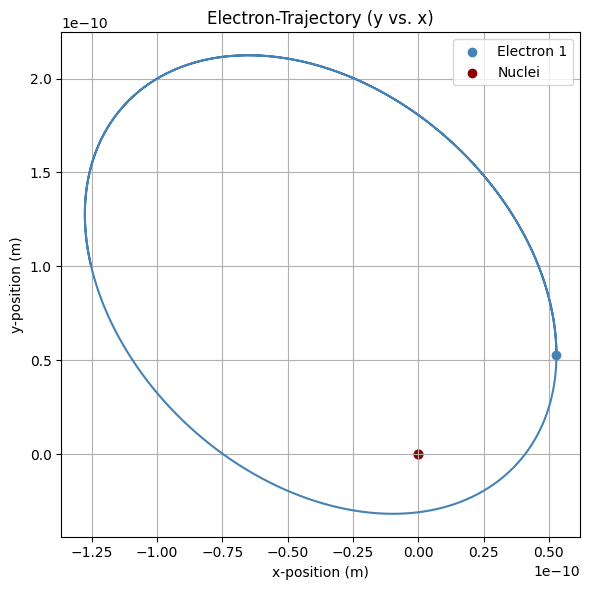

In [6]:
# Constants
k = 8.9875517923e9
q = 1.6e-19
me = 9.11e-31

nucleus_origin = [[0, 0]]  # separate variable, don't touch nuclei

def equations1(t, electron):
    
    x1, y1, vx1, vy1 = electron

    r_nucleus1_e1 = sqrt((x1 - nucleus_origin[0][0])**2 + (y1 - nucleus_origin[0][1])**2)

    fx1 = - k * q**2 * ( (x1 - nucleus_origin[0][0]) / r_nucleus1_e1**3 )
    fy1 = - k * q**2 * ( (y1 - nucleus_origin[0][1]) / r_nucleus1_e1**3 )

    ax1 = fx1 / me
    ay1 = fy1 / me

    return vx1, vy1, ax1, ay1

def system1(electron_initial_state, value=False):
    
    solution = solve_ivp(equations1, [0, 1e-15], electron_initial_state, t_eval=linspace(0, 1e-15, 6000), rtol=1e-9, atol=1e-9)
    
    x1_results, y1_results, vx1_results, vy1_results = solution.y[0], solution.y[1], solution.y[2], solution.y[3]
    
    if value == True:
        
        plt.figure(figsize=(6, 6))
        plt.plot(x1_results, y1_results, color='steelblue')
        plt.scatter(electron_initial_state[0], electron_initial_state[1], color='steelblue', label='Electron 1')
        plt.scatter([], [], color='darkred', label='Nuclei')
        for nucleus in nucleus_origin:
            plt.scatter(nucleus[0], nucleus[1], color='darkred', s=40)
        plt.title('Electron-Trajectory (y vs. x)')
        plt.xlabel('x-position (m)')
        plt.ylabel('y-position (m)')
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

system1([5.29e-11, 5.29e-11, 0, 2.18501e6], True)

***Observation:** The electron does not orbit the nucleus in a uniform circular manner, instead it forms an elliptical shape. Nevertheless, the orbit is still stable using the calculated values so the force equations used for the nucleus can be considered valid.*

## Data visualization and interpretation

### Initial Parameters

*The following plots are based on the initial parameters obtained through trial-error. The main point of interest is the symmetry in the electron orbits, where each electron is confined to one region in space. This dynamic is made clear in the relative electron x-positions; when the electrons are close they repel but get attracted to the nuclei after reaching a threshold distance. This pattern is repeated endlessly with no shift in trend. On the other hand, due to the synchronicity of the orbits, the relative y-position is always zero.* 

In [7]:
nuclei = [[-3.7e-12, 0], [3.7e-12, 0]]

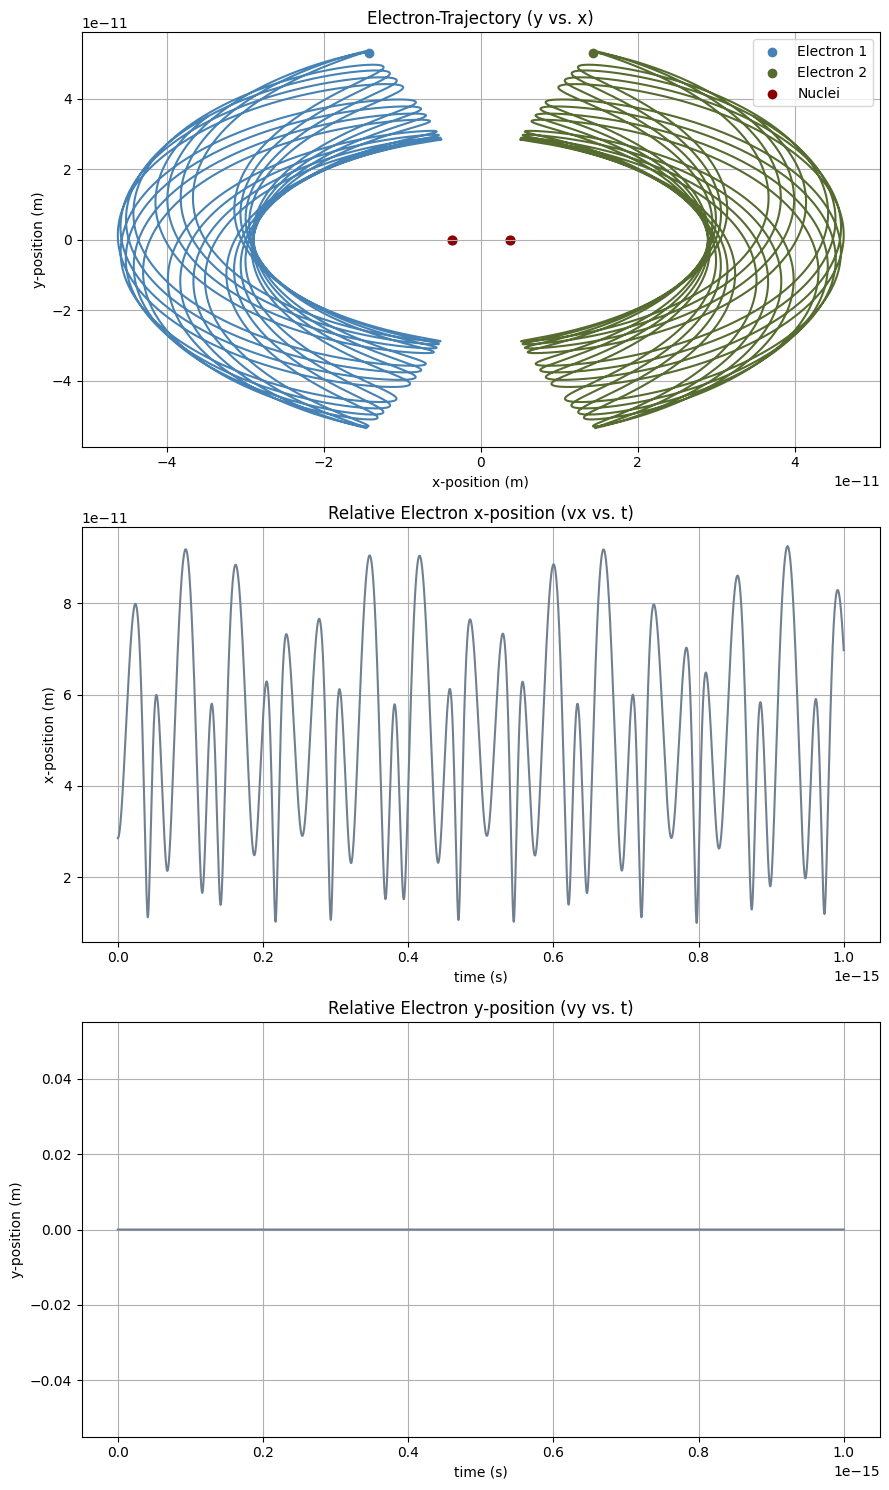

In [8]:
system([-1.428e-11, 5.29e-11, 0, 2e5, 1.428e-11, 5.29e-11, 0, 2e5], True)

### Individual Manipulation

#### Varying initial state of Electron 1 

*By varying the number of samples we notice that there are no stable orbits found with any combination of parameters. There also seems to be a constant trend at a particular position value in each plot, indicating the termination of the code at that point. In particular, the position plots for Electron 1 are steady at the point of escape from the system. This shows that the electrostatic force exerted by Electron 2 is driving the other electrons away from the nuclei to the point where the attractive electrostatic force have minimal influence on the electron. Whereas, Electron 2 approaches the closest nucleus when visualized.*

In [9]:
interact(plot_electron1, samples = ( 10, 600, 59 ))

interactive(children=(IntSlider(value=600, description='samples', max=600, min=10, step=59), Output()), _dom_c…

<function __main__.plot_electron1(samples=600)>

#### Varying initial state of Electron 2

*Similar to the manipulation of Electron 1 parameters, there are no stable orbits obtained in this combination. However, we can infer that the Electron 2 position has a more stable trend than Electron 1, where Electron 2 is escaping the system and Electron 1 is moving towards the nuclei. It is interesting to note that at lower y-velocity values the orbit positions are randomized with a general increase in position followed by a sudden drop.*

In [10]:
interact(plot_electron2, samples = ( 10, 600, 59 ))

interactive(children=(IntSlider(value=600, description='samples', max=600, min=10, step=59), Output()), _dom_c…

<function __main__.plot_electron2(samples=600)>

#### Simultaneous Manipulation

*While maintaining symmetry, there are some stable orbits observed at lower y-velocity values. This is followed by an exponential change in position values to the extent where the code terminates at the same point. With an emphasis on the stable orbits, we can see that the final x-positions of Electron 1 are about the same as its y-positions. This behavior is also visible for Electron 2 with certain exceptions. A possible conclusion can be that the orbits are stable when the x and y positions of the electrons are tending towards the nuclei, for the electrostatic forces to influence the particles in a relatively uniform manner. Also, as the y-velocity approach the speed of light the orbits become unstable, which correspond to the physical fact of electron speed always being less than the speed of light.*

In [11]:
interact(plot_simultaneous, samples = ( 10, 600, 59 ))

interactive(children=(IntSlider(value=600, description='samples', max=600, min=10, step=59), Output()), _dom_c…

<function __main__.plot_simultaneous(samples=600)>

## Synthesis and discussion

* **Findings**
    * The investigation focused on three aspects of the model: influence of velocity on system, dependence on synchronicity for stability, and alteration of physical characteristics in comparison to the standard atomic model. In addition, the investigation attempted to prove or disprove the claim made by the Saturnian model that the moving particles must have the same velocity in order to remain stable. 
    * From the above plots we can see a clear relation between y-velocity component and the stability of system. Specifically, the model remains stable at lower velocities in reference to the speed of light. For instance, in the simultaneous investigation, the largest y-velocity to achieve stability was 2.94e6 m/s after which all orbits were unstable. We know that a typical speed of an electron in a Hydrogen atom is 2.2e6 m/s, which is similar to the value found in the present model. However, the added condition is that the two electrons must have the same velocity for gain stability, since there were no stable orbits found when either one of the electrons had different velocities. As a result, the investigation proves that the Saturnian model claim can be implemented in more complex configurations such as a two-nuclei and two-electron system. 
    * Although the model seems to function only under symmetric conditions, the extent of the influence of symmetry was also tested. Turns out that for higher velocities, the symmetry no longer holds relevance and the system becomes unstable, plateauing at velocities closer to the speed of light. 
    * The structure of the Saturnian model consisted of concentric circular orbits, and the phase investigation was used to determine if the shape of the orbits changes due to a change in configuration. It is observed that the current model achieves stability at a larger orbital radii than a physical hydrogen atom orbit. Referring to the same y-velocity value, the final magnitude of position of both electrons is 8.3424e-10 m. Although it is larger than the found electron orbit, the radius is still smaller than the size of an atom. It is also peculiar that the orbits form an overall circular pattern (with some eccentricity) as a result of the introduced element of symmetry. 

* **Limitations**
    * The current model is based on empirical evidence of the structure and behavior of a hydrogen atom, therefore it is constrained to those parameters. This causes a bias in the investigation does not take into account possible anomalies.
    * A two nuclei system is difficult to achieve in a physical sense as the nuclei themselves repel each other, unless they are chemically bonded. This aspect was not explored in this investigation, hence the results found cannot be implemented in reality. 
    * The system primarily depended on symmetry, which again reduced the scope of this investigation. However, there was an attempt made to also investigate asymmetrical parameters to find exceptions to this case.
    * There are many more forces that act upon the particles that have not been considered in this project. 
    
* **Future scope**
    * Taking from the limitations, the present investigation could involve the nuclei as free-moving particle as well. This would lead to findings that are more intertwined with reality, where the investigation would focus on bringing all four charges in equilibrium. 
    * Since the Saturnian model is being investigated, mimicking the concentric orbits would more accurately prove or disproves the claims made for the model. 